# Portfolio Optimization using SCS Solver

**Goal:** Build optimal portfolio from Nifty 50 stocks

- Mean-Variance optimization
- Long only constraint
- Fully invested (weights sum to 1)

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os
import cvxpy as cp
from pathlib import Path


DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

### Data Ingestion

#### Download Data

**Data Source:** Kaggle - Nifty 50 daily prices

Downloaded using Kaggle API 

In [2]:
# 1. Download Data via KaggleHub
print("Downloading Nifty 50 data...")
cache_path = kagglehub.dataset_download("rohanrao/nifty50-stock-market-data")

# 2. Move to local folder (flattening structure)
source_path = Path(cache_path)
if source_path.is_file():
    shutil.copy2(source_path, DATA_DIR / source_path.name)
elif source_path.is_dir():
    for f in source_path.glob("**/*.csv"): # Recursive search
        shutil.copy2(f, DATA_DIR / f.name)


print("Reading CSV files...")
files = [
    f for f in DATA_DIR.glob("*.csv") 
    if "NIFTY50_all" not in f.name and "stock_metadata" not in f.name
]

print(f"Found {len(files)} files.")

df_list = []
for f in files:
    try:
        tmp = pd.read_csv(f)
        
        # Ensure consistent column names
        tmp.columns = [c.strip().lower() for c in tmp.columns]
        
        # Use filename as symbol if the column is missing
        if 'symbol' not in tmp.columns:
            tmp['symbol'] = f.stem.upper()
            
        df_list.append(tmp)
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

raw_df = pd.concat(df_list, axis=0)

Reading CSV files...
Found 50 files.


/tmp/ipykernel_1239754/1720878790.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  raw_df = pd.concat(df_list, axis=0)


### Data Cleaning

#### Filter 5 years
- Too old data = market conditions changed (different govt, policies, etc.)
- Too short = not enough data points for covariance estimation
- 5 years taken as it covers multiple market cycles (bull + bear)
- 2016-2021 includes demonetization, COVID crash, recovery - good stress test

In [3]:
raw_df.columns = [c.strip().lower() for c in raw_df.columns]

raw_df['date'] = pd.to_datetime(raw_df['date'])
START_DATE = '2016-01-01'
print(f"Filtering for 5-year window ({START_DATE} onwards)...")
raw_df = raw_df[raw_df['date'] >= START_DATE]

Filtering for 5-year window (2016-01-01 onwards)...


In [4]:
raw_df.describe(include='all')

,date,symbol,series,prev close,open,high,low,last,close,vwap,volume,turnover,trades,deliverable volume,%deliverble
count,64582,64582,64582,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.000000,64582.0,6.458200e+04,6.458200e+04,6.458200e+04,64582.000000
unique,NaN,49,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64308.0,NaN,NaN,NaN,NaN
top,NaN,ADANIPORTS,EQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,702853.0,NaN,NaN,NaN,NaN
freq,NaN,1318,64582,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
mean,2018-08-31 16:14:34.051593216,NaN,NaN,2236.422272,2239.236104,2267.907695,2207.485284,2236.649060,2236.998425,2237.653534,NaN,3.476478e+14,8.110436e+04,2.474930e+06,0.453286
min,2016-01-01 00:00:00,NaN,NaN,60.000000,59.400000,62.900000,50.000000,60.200000,60.000000,60.840000,NaN,8.818495e+11,1.950000e+02,2.860000e+02,0.029900
25%,2017-05-04 00:00:00,NaN,NaN,331.362500,331.712500,336.700000,325.800000,331.400000,331.412500,331.392500,NaN,1.015743e+14,3.313125e+04,3.983550e+05,0.316500
50%,2018-08-28 12:00:00,NaN,NaN,750.875000,751.000000,760.000000,741.225000,750.500000,751.000000,750.970000,NaN,1.959911e+14,5.817200e+04,1.251184e+06,0.457600
75%,2020-01-03 00:00:00,NaN,NaN,2063.525000,2067.237500,2091.500000,2040.000000,2065.450000,2064.187500,2066.972500,NaN,3.947338e+14,9.994400e+04,3.013276e+06,0.587100
max,2021-04-30 00:00:00,NaN,NaN,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.240000,NaN,3.564334e+16,1.643015e+06,2.325307e+08,0.979700


In [5]:
unique_symbols = raw_df['symbol'].unique()
unique_symbols.sort()

print(f"Total Unique Assets: {len(unique_symbols)}")

for ticker in unique_symbols:
    print(ticker)

Total Unique Assets: 49
ADANIPORTS
ASIANPAINT
AXISBANK
BAJAJ-AUTO
BAJAJFINSV
BAJFINANCE
BHARTIARTL
BPCL
BRITANNIA
CIPLA
COALINDIA
DRREDDY
EICHERMOT
GAIL
GRASIM
HCLTECH
HDFC
HDFCBANK
HEROMOTOCO
HINDALCO
HINDUNILVR
ICICIBANK
INDUSINDBK
INFY
IOC
ITC
JSWSTEEL
KOTAKBANK
LT
M&M
MARUTI
NESTLEIND
NTPC
ONGC
POWERGRID
RELIANCE
SBIN
SHREECEM
SUNPHARMA
TATAMOTORS
TATASTEEL
TCS
TECHM
TITAN
ULTRACEMCO
UPL
VEDL
WIPRO
ZEEL


Only 49 assets because infratel.csv is empty.

In [6]:
raw_df.isna().sum()

date                  0
symbol                0
series                0
prev close            0
open                  0
high                  0
low                   0
last                  0
close                 0
vwap                  0
volume                0
turnover              0
trades                0
deliverable volume    0
%deliverble           0
dtype: int64

In [7]:
prices = raw_df.pivot_table(index='date', columns='symbol', values='close')
prices = prices.sort_index()

prices.head()

symbol,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
date,,,,,,,,,,,,,,,,,,,,,
2016-01-01,267.55,878.75,449.90,2518.00,1983.80,6095.85,340.50,896.05,2986.40,655.35,...,401.90,257.40,2416.40,520.05,352.05,2824.00,440.35,91.65,556.45,432.90
2016-01-04,257.95,880.80,438.40,2483.35,1959.50,6052.45,326.80,891.45,2972.60,645.65,...,377.05,256.90,2369.60,516.40,351.40,2749.15,433.85,88.95,557.70,421.95
2016-01-05,255.70,900.65,436.45,2502.35,1946.00,5997.85,323.45,902.65,2966.70,640.85,...,374.45,274.30,2348.95,521.90,347.70,2733.05,435.30,92.40,556.90,425.05
2016-01-06,251.80,886.40,430.70,2485.50,1938.55,6107.25,322.20,912.30,3001.70,652.10,...,365.90,268.75,2381.60,525.10,347.85,2735.30,443.35,88.90,555.10,423.15
2016-01-07,245.00,872.35,409.25,2419.25,1927.05,6106.30,322.35,884.25,2946.55,637.45,...,343.55,249.90,2371.25,510.80,344.05,2667.70,417.40,81.15,549.85,415.40


In [8]:
# 1. Compute Daily Returns
returns = prices.pct_change().dropna()

# 2. Annualize Parameters (252 trading days)
# Mu = Expected Annual Return
# Sigma = Annualized Covariance Matrix
mu = returns.mean().values * 252
sigma = returns.cov().values * 252
tickers = returns.columns.tolist()

print(f"Optimization Universe: {len(tickers)} Assets")
print(f"Avg Expected Return: {np.mean(mu):.2%}")
print(f"Avg Annual Risk: {np.mean(np.sqrt(np.diag(sigma))):.2%}")

Optimization Universe: 49 Assets
Avg Expected Return: 12.54%
Avg Annual Risk: 36.45%


In [9]:
print(f"Dimensions: {prices.shape} (Rows x Assets)")
print(f"Date Range: {prices.index.min().date()} to {prices.index.max().date()}")

Dimensions: (1318, 49) (Rows x Assets)
Date Range: 2016-01-01 to 2021-04-30


In [10]:
print("Dimensions of Returns Matrix:", returns.shape)

print("Dimensions of Mu Vector:",mu.shape)
print("Dimensions of Sigma Matrix:",sigma.shape)

Dimensions of Returns Matrix: (1317, 49)
Dimensions of Mu Vector: (49,)
Dimensions of Sigma Matrix: (49, 49)


### Mean-Variance Optimization (Markowitz)
We solve the scalarized multi-objective optimization problem where we minimize volatility while maximizing returns, controlled by the risk aversion parameter $\gamma$.

$$
\begin{align*}
& \text{minimize} && \frac{1}{2} w^T \Sigma w - \gamma \mu^T w \\
& \text{subject to} && 1^T w = 1 \\
& && w \ge 0
\end{align*}
$$

**Where:**
* $w \in \mathbb{R}^n$: Portfolio weights (Decision Variable)
* $\Sigma \in \mathbb{R}^{n \times n}$: Covariance matrix (Risk)
* $\gamma \in \mathbb{R}_{\ge 0}$: Risk aversion parameter ($\gamma \to 0$ implies max safety)

### Splitting Conic Solver (SCS)
A first-order method that solves large-scale Convex Cone problems using **ADMM** (Alternating Direction Method of Multipliers). It splits the problem into a linear system solution and a projection onto a cone.

**Algorithm Steps:**

1.  **Subspace Projection (Linear System):**
    Solves the unconstrained system involving the problem data ($\Sigma, \mu$) to satisfy the linear equations (KKT conditions).
    $$\tilde{w}^{k+1} = (I + \Sigma)^{-1} (w^k + \gamma \mu - y^k)$$

2.  **Cone Projection (Constraints):**
    Projects the result onto the feasible set (The Non-Negative Orthant + Simplex).
    $$w^{k+1} = \Pi_{\mathcal{K}}(\tilde{w}^{k+1} + y^k)$$
    *(This step forces negative weights to zero and ensures sum = 1)*

3.  **Dual Update:**
    Updates the dual variables (Lagrange multipliers) to enforce consensus between the two steps.
    $$y^{k+1} = y^k + \tilde{w}^{k+1} - w^{k+1}$$

In [11]:
# Risk Aversion Parameters (Gamma)
gammas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

n_assets = len(tickers)
w = cp.Variable(n_assets)
gamma_param = cp.Parameter(nonneg=True)

# Objective: Minimize (0.5 * Risk - Gamma * Return)
port_ret = mu @ w
port_risk = cp.quad_form(w, sigma)
objective = cp.Minimize(0.5 * port_risk - gamma_param * port_ret)

# Constraints: Fully Invested, Long Only
constraints = [
    cp.sum(w) == 1,
    w >= 0
]

prob = cp.Problem(objective, constraints)
results = []

print("Running SCS Solver...")
print("-" * 65)
print(f"{'Gamma':<6} | {'Return':<10} | {'Risk':<10} | {'Sharpe':<8} | {'Status'}")
print("-" * 65)

for g in gammas:
    gamma_param.value = g
    prob.solve(solver=cp.SCS, verbose=False)
    
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt_clean = w.value.copy()
        wt_clean[wt_clean < 1e-4] = 0.0
        wt_clean = wt_clean / np.sum(wt_clean)
        
        p_ret = wt_clean @ mu
        p_vol = np.sqrt(wt_clean.T @ sigma @ wt_clean)
        sharpe = p_ret / p_vol
        
        s = pd.Series(wt_clean, index=tickers).sort_values(ascending=False)
        top3 = ", ".join([f"{i}({v:.0%})" for i, v in s.head(3).items()])
        
        results.append({
            "Gamma": g, "Return": p_ret, "Risk": p_vol, 
            "Sharpe": sharpe, "Top Holdings": top3
        })
        
        print(f"{g:<6} | {p_ret:.2%}     | {p_vol:.2%}     | {sharpe:.2f}     | {prob.status}")
    else:
        print(f"{g:<6} | FAILED     |            |          | {prob.status}")

df_res = pd.DataFrame(results).set_index("Gamma")

Running SCS Solver...
-----------------------------------------------------------------
Gamma  | Return     | Risk       | Sharpe   | Status
-----------------------------------------------------------------
0.1    | 25.73%     | 17.97%     | 1.43     | optimal
0.5    | 37.31%     | 28.98%     | 1.29     | optimal
1.0    | 38.78%     | 32.50%     | 1.19     | optimal
2.0    | 39.65%     | 35.88%     | 1.10     | optimal
5.0    | 39.85%     | 37.08%     | 1.07     | optimal
10.0   | 39.85%     | 37.08%     | 1.07     | optimal


### Efficient Frontier

In [12]:
# Industry mapping for color coding (used later in per-gamma sections)
industry_map = {
    'NESTLEIND': 'FMCG', 'HINDUNILVR': 'FMCG', 'BRITANNIA': 'FMCG', 'ITC': 'FMCG',
    'BAJAJFINSV': 'Finance', 'BAJFINANCE': 'Finance', 'HDFCBANK': 'Finance', 'ICICIBANK': 'Finance',
    'KOTAKBANK': 'Finance', 'AXISBANK': 'Finance', 'SBIN': 'Finance', 'INDUSINDBK': 'Finance', 'HDFC': 'Finance',
    'TITAN': 'Consumer', 'ASIANPAINT': 'Consumer', 'MARUTI': 'Auto', 'HEROMOTOCO': 'Auto',
    'BAJAJ-AUTO': 'Auto', 'EICHERMOT': 'Auto', 'MM': 'Auto', 'TATAMOTORS': 'Auto',
    'TCS': 'IT', 'INFY': 'IT', 'WIPRO': 'IT', 'HCLTECH': 'IT', 'TECHM': 'IT',
    'RELIANCE': 'Energy', 'ONGC': 'Energy', 'BPCL': 'Energy', 'IOC': 'Energy', 'GAIL': 'Energy',
    'POWERGRID': 'Power', 'NTPC': 'Power', 'COALINDIA': 'Power',
    'TATASTEEL': 'Metals', 'HINDALCO': 'Metals', 'JSWSTEEL': 'Metals', 'VEDL': 'Metals',
    'DRREDDY': 'Pharma', 'SUNPHARMA': 'Pharma', 'CIPLA': 'Pharma',
    'ADANIPORTS': 'Infra', 'LT': 'Infra', 'GRASIM': 'Infra', 'ULTRACEMCO': 'Cement', 'SHREECEM': 'Cement',
    'BHARTIARTL': 'Telecom', 'INFRATEL': 'Telecom', 'ZEEL': 'Media', 'UPL': 'Agri'
}

industry_colors = {
    'FMCG': '#2ecc71', 'Finance': '#3498db', 'Consumer': '#9b59b6', 'Auto': '#e74c3c',
    'IT': '#1abc9c', 'Energy': '#f39c12', 'Power': '#e67e22', 'Metals': '#95a5a6',
    'Pharma': '#d35400', 'Infra': '#8e44ad', 'Cement': '#7f8c8d', 'Telecom': '#16a085',
    'Media': '#c0392b', 'Agri': '#27ae60'
}

asset_vols = np.sqrt(np.diag(sigma))

# Individual stock risk-return profile
stock_stats = pd.DataFrame({
    'Stock': tickers,
    'Return': [f"{r:.2%}" for r in mu],
    'Risk': [f"{v:.2%}" for v in asset_vols]
}).sort_values('Stock').reset_index(drop=True)
stock_stats



,Stock,Return,Risk
0,ADANIPORTS,26.14%,37.09%
1,ASIANPAINT,23.69%,26.06%
2,AXISBANK,16.39%,38.48%
3,BAJAJ-AUTO,11.57%,26.55%
4,BAJAJFINSV,39.85%,37.08%
5,BAJFINANCE,33.17%,57.38%
6,BHARTIARTL,14.59%,34.42%
7,BPCL,-1.67%,46.78%
8,BRITANNIA,9.73%,33.96%
9,CIPLA,10.21%,28.17%


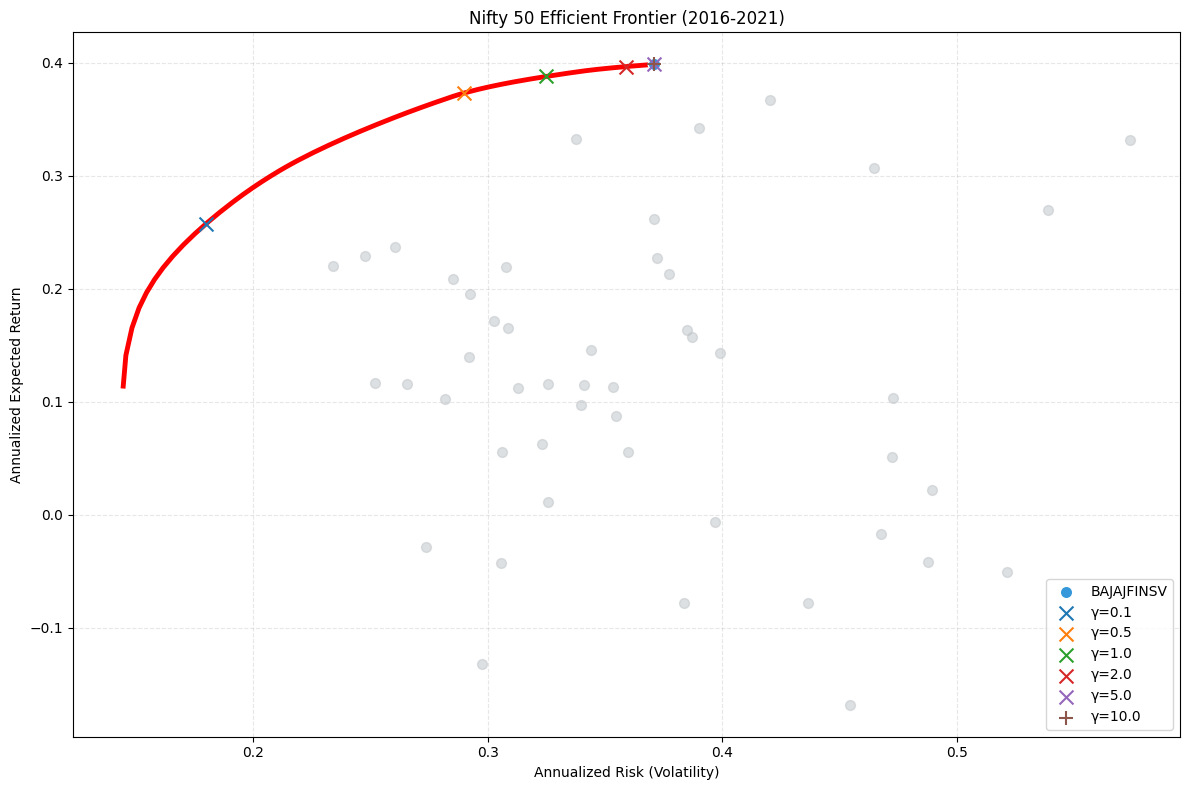

In [ ]:
marker_gammas = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
gamma_range = np.unique(np.sort(np.concatenate([np.linspace(0.001, 20, 2000), marker_gammas])))

frontier_risks, frontier_returns = [], []
for g in gamma_range:
    gamma_param.value = g
    prob.solve(solver=cp.SCS, verbose=False)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt = np.maximum(w.value, 0); wt /= wt.sum()
        frontier_returns.append(wt @ mu)
        frontier_risks.append(np.sqrt(wt @ sigma @ wt))

# Color scheme for gamma markers
gamma_colors = {0.1: '#1f77b4', 0.5: '#ff7f0e', 1.0: '#2ca02c', 2.0: '#d62728', 5.0: '#9467bd', 10.0: '#8c564b'}

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(asset_vols, mu, color='#bdc3c7', alpha=0.5, s=50, zorder=2)  # Individual stocks
ax.plot(frontier_risks, frontier_returns, 'r-', lw=3.5, zorder=5)  # Frontier

# Highlight BAJAJFINSV separately (it overlaps with gamma=5,10)
bajaj_idx = tickers.index('BAJAJFINSV')
ax.scatter(asset_vols[bajaj_idx], mu[bajaj_idx], color='#3498db', s=80, zorder=6, edgecolor='white', lw=1, label='BAJAJFINSV')

# Gamma markers with color coding
for g in marker_gammas:
    if g in df_res.index:
        marker = '+' if g == 10.0 else 'x'
        ax.scatter(df_res.loc[g, 'Risk'], df_res.loc[g, 'Return'], marker=marker, s=100, 
                   c=gamma_colors[g], zorder=10, lw=1.5, label=f'γ={g}')

ax.set(title="Nifty 50 Efficient Frontier (2016-2021)", xlabel="Annualized Risk (Volatility)", ylabel="Annualized Expected Return")
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Optimal Portfolio Weights

In [14]:
portfolio_results = []
for g in marker_gammas:
    gamma_param.value = g
    prob.solve(solver=cp.SCS, verbose=False)
    if prob.status in ['optimal', 'optimal_inaccurate']:
        wt = np.maximum(w.value, 0); wt /= wt.sum()
        wt[wt < 1e-4] = 0  # Clean small weights
        weights_str = ", ".join([f"{t}({v:.0%})" for t, v in sorted(zip(tickers, wt), key=lambda x: -x[1]) if v > 0])
        portfolio_results.append({
            'Gamma': g,
            'Return': f"{wt @ mu:.2%}",
            'Risk': f"{np.sqrt(wt @ sigma @ wt):.2%}",
            'Portfolio Weights': weights_str
        })

pd.DataFrame(portfolio_results)

,Gamma,Return,Risk,Portfolio Weights
0,0.1,25.73%,17.97%,"NESTLEIND(19%), HINDUNILVR(18%), BAJAJFINSV(13..."
1,0.5,37.31%,28.98%,"BAJAJFINSV(52%), TITAN(26%), HINDALCO(17%), TA..."
2,1.0,38.78%,32.50%,"BAJAJFINSV(73%), HINDALCO(20%), TITAN(7%)"
3,2.0,39.65%,35.88%,"BAJAJFINSV(94%), HINDALCO(6%)"
4,5.0,39.85%,37.08%,BAJAJFINSV(100%)
5,10.0,39.85%,37.08%,BAJAJFINSV(100%)


## Why These Stocks?

For each gamma value, we show:
1. **Efficient frontier plot** with the gamma point marked and portfolio stocks highlighted
2. **Correlation heatmap** (for diversified portfolios) showing why these stocks work together
3. **Conclusion** explaining the solver's logic

**Key Insight:** As gamma increases, portfolio goes from diversified (many stocks) to concentrated (single stock)

### Gamma = 0.1 (Safe Portfolio, Return = 25.73%, Risk = 17.97%)

**Return and Risk of the portfolio stocks**

In [15]:
current_gamma = 0.1
portfolio_stocks_01 = ['NESTLEIND', 'HINDUNILVR', 'BAJAJFINSV', 'TITAN', 'ASIANPAINT', 'DRREDDY', 'TATASTEEL', 'POWERGRID', 'TCS', 'ADANIPORTS', 'RELIANCE', 'TECHM', 'KOTAKBANK', 'HINDALCO']

stock_stats[stock_stats['Stock'].isin(portfolio_stocks_01)]

,Stock,Return,Risk
0,ADANIPORTS,26.14%,37.09%
1,ASIANPAINT,23.69%,26.06%
4,BAJAJFINSV,39.85%,37.08%
11,DRREDDY,13.94%,29.18%
19,HINDALCO,36.71%,42.03%
20,HINDUNILVR,22.06%,23.40%
27,KOTAKBANK,20.86%,28.53%
31,NESTLEIND,22.88%,24.77%
34,POWERGRID,11.69%,25.19%
35,RELIANCE,21.35%,37.74%


**Efficient Frontier Plot:** Cross marker shows gamma=0.1 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

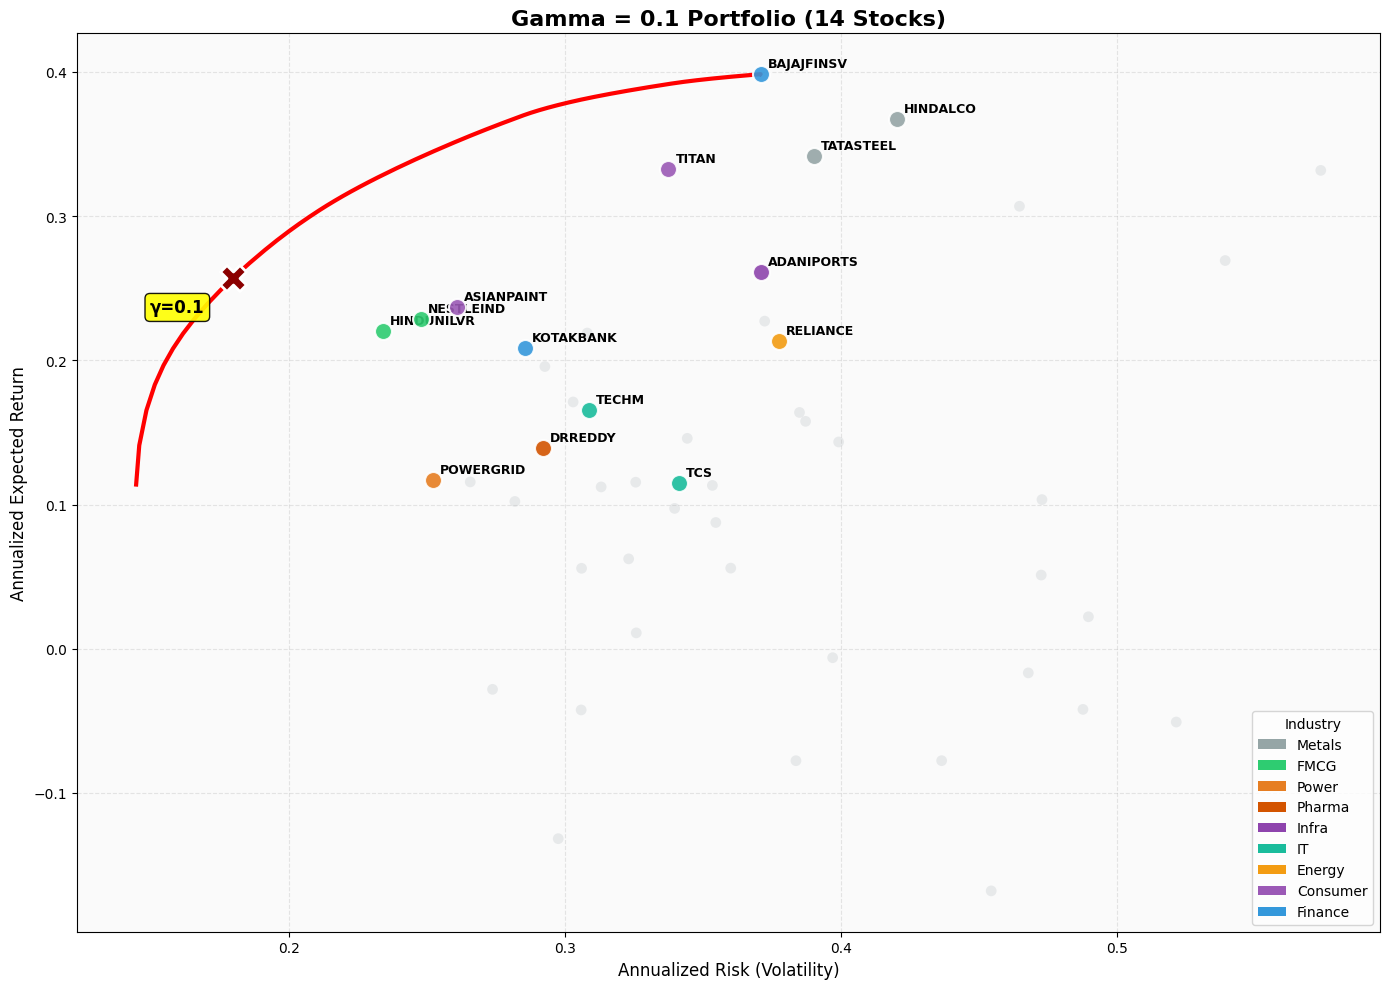

In [16]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_01:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_01:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.1
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_01)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (14 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

**Correlation Heatmap:** Lower correlation between stocks = better diversification = lower portfolio risk

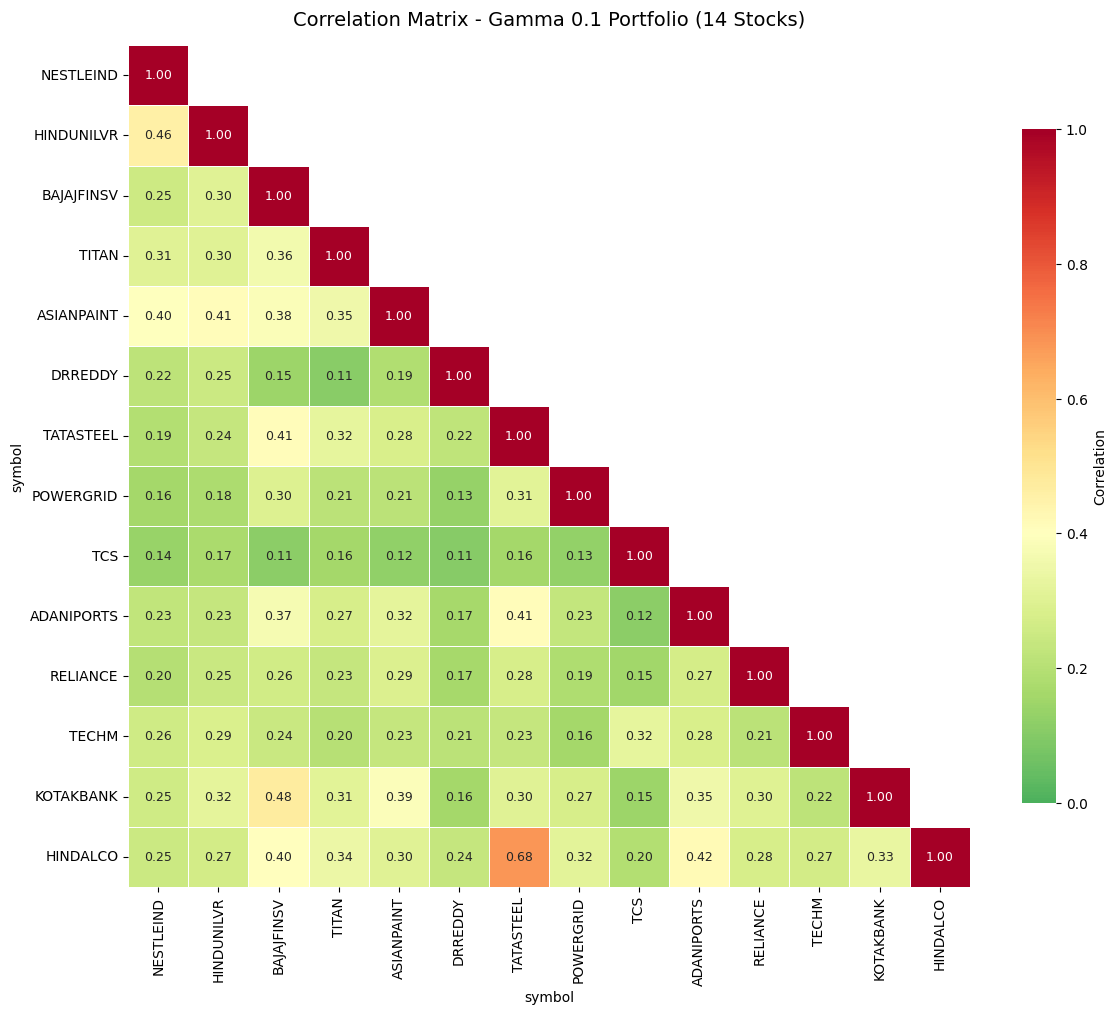

Average Pairwise Correlation: 0.26


In [17]:
corr_matrix_01 = returns[portfolio_stocks_01].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix_01, dtype=bool), k=1)
sns.heatmap(corr_matrix_01, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.1 Portfolio (14 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_01, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_01 = corr_matrix_01.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_01:.2f}")

**Strategy:** Maximum Safety. The solver minimizes risk by defining the efficient boundary of the asset universe.

**Portfolio Composition:** 14 Stocks

| Stock | Weight | Industry | Return | Risk | Why? (Simplified Rationale) |
| --- | --- | --- | --- | --- | --- |
| **NESTLEIND** | **19%** | FMCG | 22.88% | 24.77% | **Low Risk & Correlation:** Very stable stock (Defensive) + moves differently from volatile sectors. |
| **HINDUNILVR** | **18%** | FMCG | 22.06% | 23.40% | **Low Risk & Correlation:** Lowest volatility in the list. Protects capital when market falls. |
| **BAJAJFINSV** | **13%** | Finance | 39.85% | 37.08% | **Near Efficient Frontier:** Offers the best individual return for its risk level. |
| **TITAN** | **13%** | Consumer | 33.27% | 33.74% | **Near Efficient Frontier:** High growth stock that justifies its volatility. |
| **ASIANPAINT** | **9%** | Consumer | 23.69% | 26.06% | **Near Efficient Frontier:** Consistent performance; sits close to the optimal line. |
| **DRREDDY** | **7%** | Pharma | 13.94% | 29.18% | **Low Correlation:** Pharma stocks often rise when the economy slows down. |
| **TATASTEEL** | **7%** | Metals | 34.20% | 39.00% | **Near Efficient Frontier:** High returns push the portfolio up the curve. |
| **POWERGRID** | **4%** | Power | 11.69% | 25.19% | **Low Risk & Correlation:** Boring, steady utility stock that ignores market crashes. |
| **TCS** | **3%** | IT | 11.53% | 34.11% | **Low Correlation:** IT sector cycles are different from domestic sectors. |
| **ADANIPORTS** | **2%** | Infra | 26.14% | 37.09% | **Near Efficient Frontier:** Good risk-reward trade-off in infrastructure. |
| **RELIANCE** | **1%** | Energy | 21.35% | 37.74% | **Diversifier:** Adds exposure to sectors not covered by others. |
| **TECHM** | **1%** | IT | 16.53% | 30.85% | **Diversifier:** Small addition to balance the IT exposure. |
| **KOTAKBANK** | **1%** | Finance | 20.86% | 28.53% | **Near Efficient Frontier:** One of the most stable banking stocks. |
| **HINDALCO** | **1%** | Metals | 36.71% | 42.03% | **Near Efficient Frontier:** High return potential improves the average. |

**Conclusion: The Efficient Perimeter**

* **The "Hollow" Cloud:** The solver selected only the "Boundary Assets" (The Efficient Perimeter), completely ignoring the stocks located in the middle of the cloud.
* **Convexity Principle:**
    * **The Return Engines (Bajaj/Titan):** These pull the portfolio *up* (Higher Return).
    * **The Safety Anchors (Nestle/HUL):** These pull the portfolio *left* (Lower Risk). They are selected because they are individually safe (low volatility) AND they don't move with the market.
    * **The Diversifiers (TCS/Pharma):** These smooth the connection between safety and growth.


* **Result:** The combination of these specific boundary assets creates a portfolio that bulges outward and to the left of the individual stocks. This explains why the Optimized Portfolio (Red Line) has significantly better risk-adjusted returns than any single stock (Grey Dots) could achieve on its own.

### Gamma = 0.5 (Moderate Portfolio, Return = 37.31%, Risk = 28.98%)

**Return and Risk of the portfolio stocks**

In [18]:
current_gamma = 0.5
portfolio_stocks_05 = ['BAJAJFINSV', 'TITAN', 'HINDALCO', 'TATASTEEL']

stock_stats[stock_stats['Stock'].isin(portfolio_stocks_05)]

,Stock,Return,Risk
4,BAJAJFINSV,39.85%,37.08%
19,HINDALCO,36.71%,42.03%
40,TATASTEEL,34.20%,39.00%
43,TITAN,33.27%,33.74%


**Efficient Frontier Plot:** Cross marker shows gamma=0.5 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

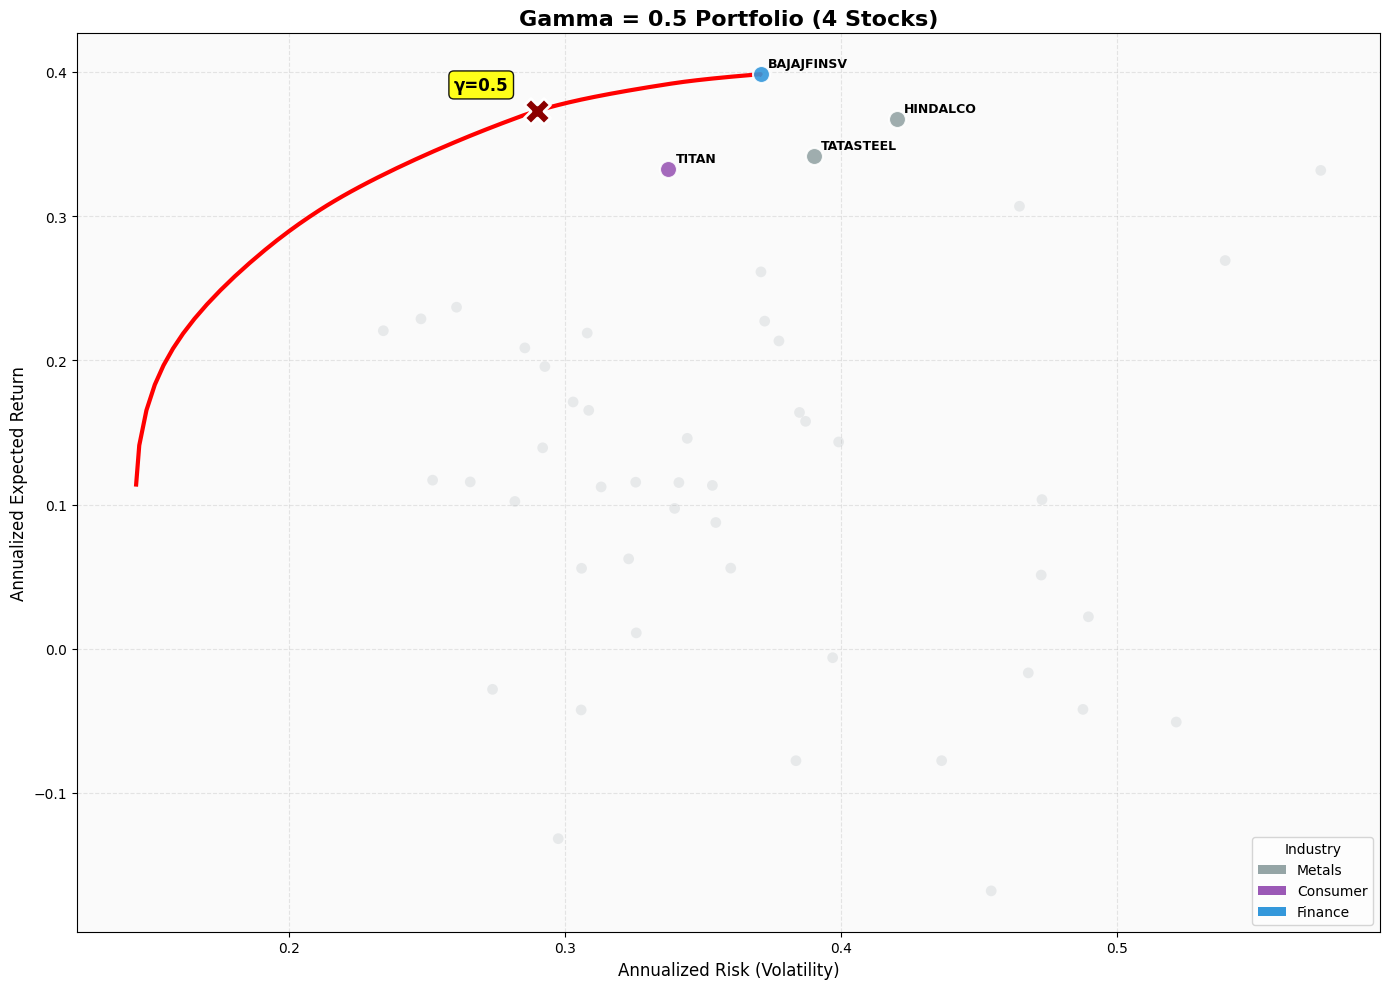

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_05:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_05:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=0.5
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(-60, 15), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_05)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (4 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

**Correlation Heatmap:** With only 4 stocks, correlation pattern is simpler but still shows diversification benefit

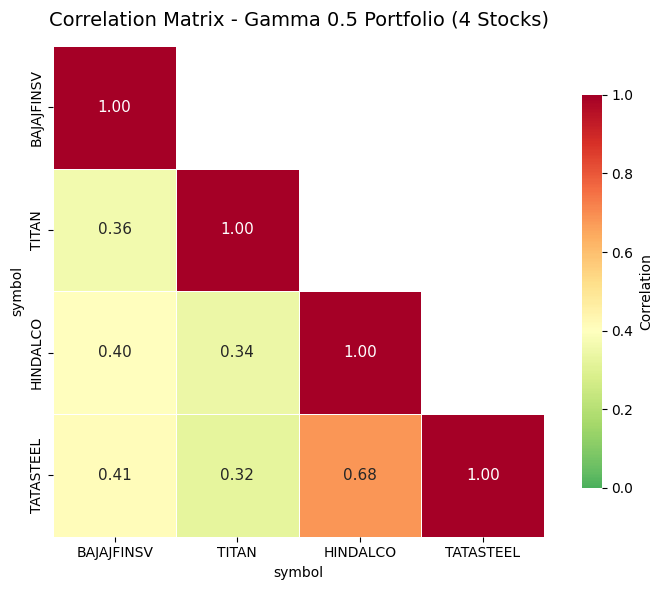

Average Pairwise Correlation: 0.42


In [20]:
# Gamma 0.5 - Correlation Heatmap
corr_matrix_05 = returns[portfolio_stocks_05].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix_05, dtype=bool), k=1)
sns.heatmap(corr_matrix_05, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 11},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 0.5 Portfolio (4 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_05, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_05 = corr_matrix_05.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_05:.2f}")

**Strategy:** Balanced Growth. The solver sacrifices safety to target higher returns.

**Portfolio Composition:** 4 Stocks

| Stock | Weight | Industry | Return | Risk | Why? (Simplified Rationale) |
| --- | --- | --- | --- | --- | --- |
| **BAJAJFINSV** | **52%** | Finance | 39.85% | 37.08% | **Highest Efficiency:** Has the best risk-to-reward ratio in the entire dataset. Solver maximizes weight here. |
| **TITAN** | **26%** | Consumer | 33.27% | 33.74% | **High Return:** consistent high performance; allows the portfolio to capture consumption growth. |
| **HINDALCO** | **17%** | Metals | 36.71% | 42.03% | **High Return:** Volatile stock, but picked because its high returns raise the portfolio average. |
| **TATASTEEL** | **5%** | Metals | 34.20% | 39.00% | **High Return:** Added to increase exposure to the high-return metals sector. |

**Conclusion (Gamma 0.5)**

The solver changed its behavior here:

* **Dropped Safety Stocks:** It removed **Nestle and HUL**. Their returns (~22%) were too low for this risk target. The solver stopped balancing risk and started prioritizing profit.
* **High Concentration:** The portfolio shrank from 14 stocks to just 4. The solver removed the average performers and put money only in the top 4 winners.
* **Sector Selection:** It picked **Finance and Metals**. These are high-risk, high-return sectors. The solver accepts the volatility because the math shows these stocks give the maximum possible return.

### Gamma = 1.0 (Balanced Portfolio, Return = 38.78%, Risk = 32.50%)

**Return and Risk of the portfolio stocks**

In [21]:
current_gamma = 1.0
portfolio_stocks_10 = ['BAJAJFINSV', 'HINDALCO', 'TITAN']

stock_stats[stock_stats['Stock'].isin(portfolio_stocks_10)]

,Stock,Return,Risk
4,BAJAJFINSV,39.85%,37.08%
19,HINDALCO,36.71%,42.03%
43,TITAN,33.27%,33.74%


**Efficient Frontier Plot:** Cross marker shows gamma=1.0 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

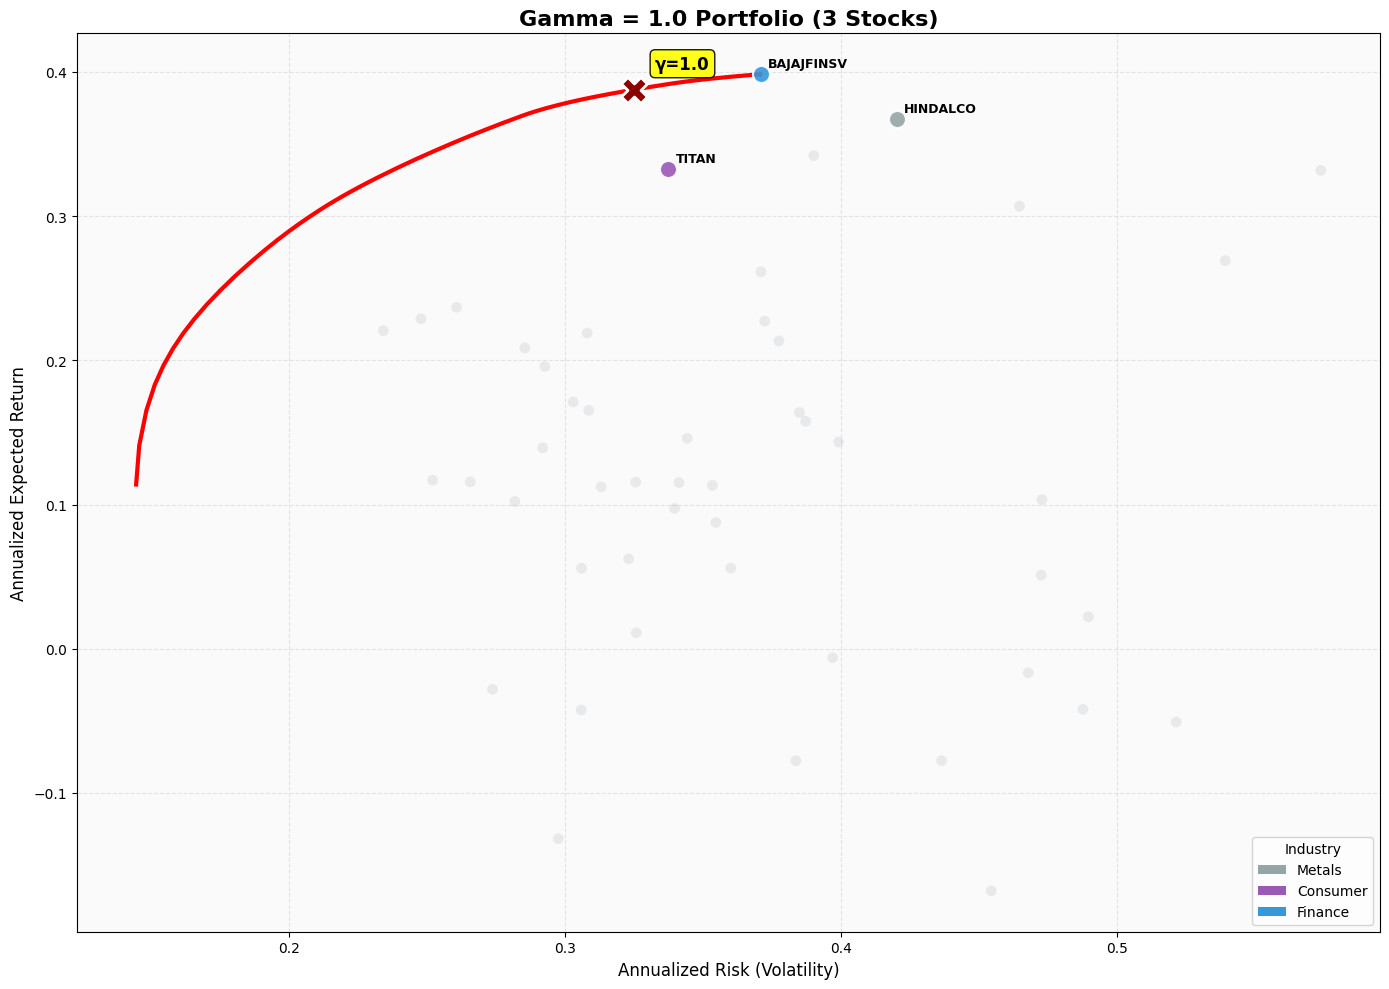

In [22]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_10:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_10:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=1.0
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(15, 15), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_10)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (3 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

**Correlation Heatmap:** 3 stocks - limited diversification but still some cross-sector benefit

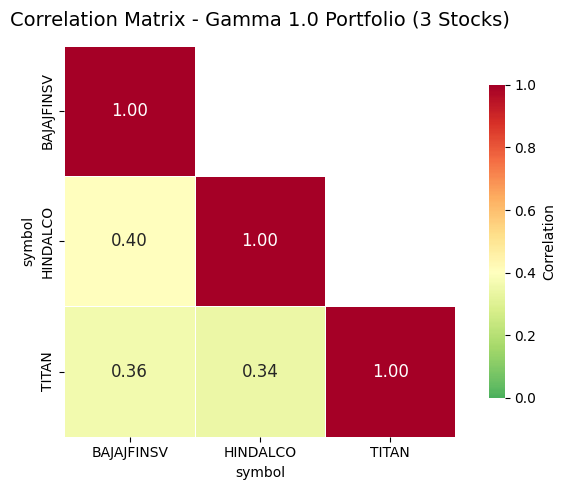

Average Pairwise Correlation: 0.37


In [23]:
corr_matrix_10 = returns[portfolio_stocks_10].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix_10, dtype=bool), k=1)
sns.heatmap(corr_matrix_10, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 12},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 1.0 Portfolio (3 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Average correlation
mask_avg = np.ones_like(corr_matrix_10, dtype=bool)
np.fill_diagonal(mask_avg, False)
avg_corr_10 = corr_matrix_10.values[mask_avg].mean()
print(f"Average Pairwise Correlation: {avg_corr_10:.2f}")

**Strategy:** Growth Focus. The solver now prioritizes high returns significantly more than risk reduction.

**Portfolio Composition:** 3 Stocks

| Stock | Weight | Industry | Return | Risk | Why? (Simplified Rationale) |
| --- | --- | --- | --- | --- | --- |
| **BAJAJFINSV** | **73%** | Finance | 39.85% | 37.08% | **Highest Efficiency:** The solver puts nearly three-quarters of the money here because it has the best performance history. |
| **HINDALCO** | **20%** | Metals | 36.71% | 42.03% | **High Return:** Chosen to boost the overall portfolio return, despite its high volatility. |
| **TITAN** | **7%** | Consumer | 33.27% | 33.74% | **High Return:** Kept as a small addition to capture growth in the consumer sector. |

**Conclusion (Gamma 1.0)**

The solver continues to narrow down the portfolio:

* **Extreme Concentration:** The portfolio is now just 3 stocks. The solver has removed **Tata Steel** because holding two metal stocks was unnecessary. It kept only **Hindalco** because it offered slightly better numbers for this specific mix.
* **Bajaj Dominance:** **Bajaj Finserv** now makes up 73% of the portfolio. The math shows that diversifying away from this stock lowers the potential profit too much, so the solver concentrates most of the capital here.
* **No Safety:** There are no "safety" or "low correlation" stocks left. The portfolio is purely aggressive, aiming for the highest possible returns regardless of the market bumps.

### Gamma = 2.0 (Growth Portfolio, Return = 39.65%, Risk = 35.88%)

**Return and Risk of the portfolio stocks**

In [24]:
current_gamma = 2.0
portfolio_stocks_20 = ['BAJAJFINSV', 'HINDALCO']

stock_stats[stock_stats['Stock'].isin(portfolio_stocks_20)]

,Stock,Return,Risk
4,BAJAJFINSV,39.85%,37.08%
19,HINDALCO,36.71%,42.03%


**Efficient Frontier Plot:** Cross marker shows gamma=2.0 position. Portfolio stocks are color-coded by industry with labels. Grey dots = stocks not in portfolio.

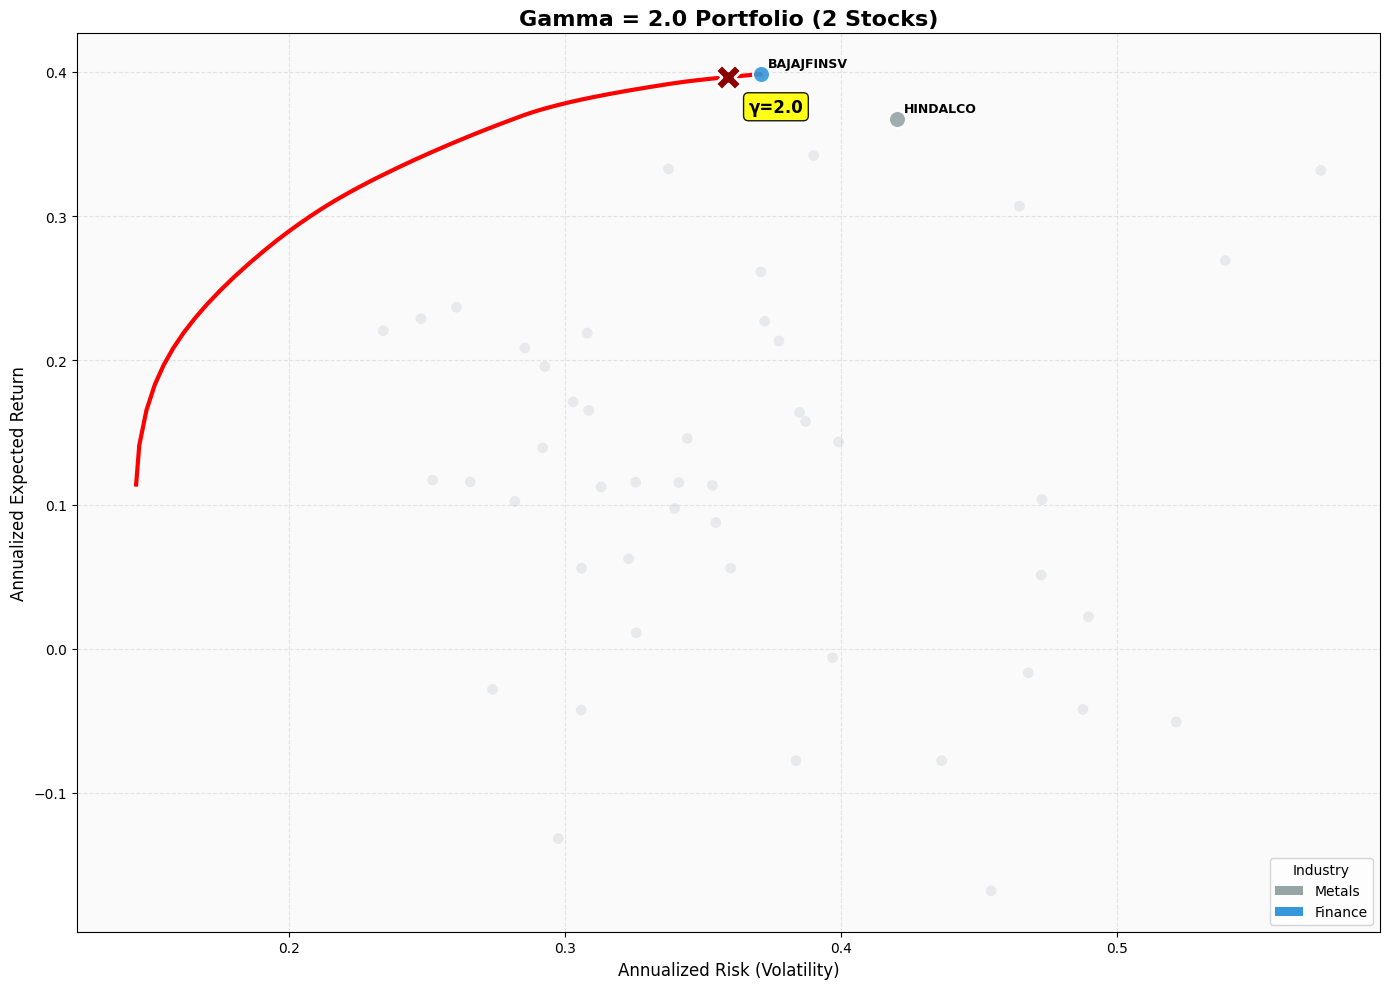

In [25]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_20:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stocks with industry colors + labels
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_20:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=150, edgecolor='white', linewidth=1.5, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(5, 5), textcoords='offset points', 
                    fontsize=9, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross marker for gamma=2.0
ax.scatter(df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return'], 
           marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
ax.annotate(f"γ={current_gamma}", (df_res.loc[current_gamma, 'Risk'], df_res.loc[current_gamma, 'Return']), 
            xytext=(15, -25), textcoords='offset points', fontsize=12, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend for industries present in portfolio
from matplotlib.patches import Patch
portfolio_industries = set(industry_map.get(s, 'Other') for s in portfolio_stocks_20)
legend_elements = [Patch(facecolor=industry_colors[ind], label=ind) for ind in portfolio_industries if ind in industry_colors]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title(f"Gamma = {current_gamma} Portfolio (2 Stocks)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

**Correlation Heatmap:** Only 2 stocks - simple correlation check

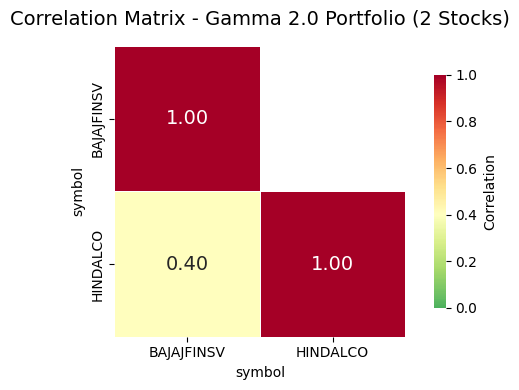

Correlation between BAJAJFINSV and HINDALCO: 0.40


In [26]:
# Gamma 2.0 - Correlation Heatmap
corr_matrix_20 = returns[portfolio_stocks_20].corr()

fig, ax = plt.subplots(figsize=(6, 4))
mask = np.triu(np.ones_like(corr_matrix_20, dtype=bool), k=1)
sns.heatmap(corr_matrix_20, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            mask=mask, vmin=0, vmax=1, center=0.4,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 14},
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})

ax.set_title('Correlation Matrix - Gamma 2.0 Portfolio (2 Stocks)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Correlation between the two stocks
corr_value = corr_matrix_20.loc['BAJAJFINSV', 'HINDALCO']
print(f"Correlation between BAJAJFINSV and HINDALCO: {corr_value:.2f}")

**Strategy:** Aggressive Growth. The solver cares almost exclusively about returns and barely penalizes risk.

**Portfolio Composition:** 2 Stocks

| Stock | Weight | Industry | Return | Risk | Why? (Simplified Rationale) |
| --- | --- | --- | --- | --- | --- |
| **BAJAJFINSV** | **94%** | Finance | 39.85% | 37.08% | **The Solo Act:** It dominates the portfolio because no other stock comes close to its historical performance. |
| **HINDALCO** | **6%** | Metals | 36.71% | 42.03% | **The Kicker:** A tiny allocation kept just because its high returns add a small boost. |

**Conclusion (Gamma 2.0)**

The portfolio has essentially become a single bet:

* **Near-Total Concentration:** We are down to just 2 stocks. The solver dropped **Titan** because even its 33% return wasn't high enough anymore compared to Bajaj's 40%.
* **All-In on the Winner:** **Bajaj Finserv** is now 94% of the portfolio. The solver sees no mathematical reason to diversify when one stock is so much better than the rest.
* **End of Diversification:** At this level, the solver isn't trying to "manage risk" or "hedge." It is simply chasing the maximum possible profit, regardless of how bumpy the ride gets.

### Gamma = 5.0 and 10.0 (Aggressive Portfolio, Return = 39.85%, Risk = 37.08%)

**Return and Risk of the portfolio stocks**

In [27]:
portfolio_stocks_high = ['BAJAJFINSV']

stock_stats[stock_stats['Stock'].isin(portfolio_stocks_high)]

,Stock,Return,Risk
4,BAJAJFINSV,39.85%,37.08%


**Efficient Frontier Plot:** Cross markers show gamma=5.0 and gamma=10.0 positions. Single portfolio stock is highlighted. Grey dots = all other stocks.

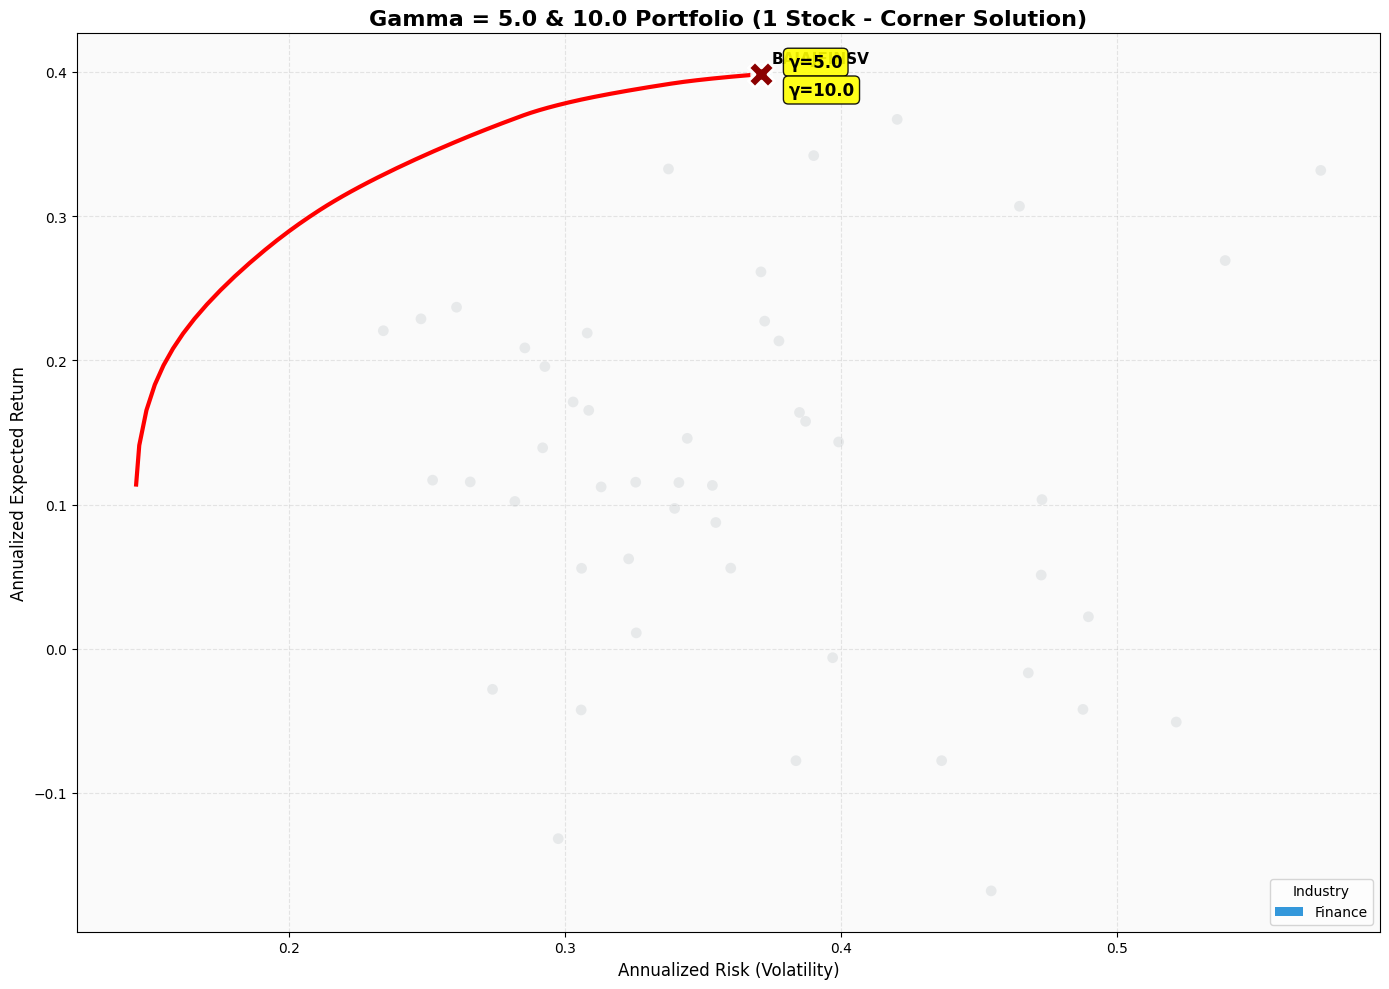

In [28]:
fig, ax = plt.subplots(figsize=(14, 10))

# Non-portfolio stocks in grey (no labels)
for i, ticker in enumerate(tickers):
    if ticker not in portfolio_stocks_high:
        ax.scatter(asset_vols[i], mu[i], color='#bdc3c7', alpha=0.3, s=60, edgecolor='none')

# Portfolio stock with industry color + label
for i, ticker in enumerate(tickers):
    if ticker in portfolio_stocks_high:
        industry = industry_map.get(ticker, 'Other')
        color = industry_colors.get(industry, '#bdc3c7')
        ax.scatter(asset_vols[i], mu[i], color=color, alpha=0.9, s=200, edgecolor='white', linewidth=2, zorder=5)
        ax.annotate(ticker, (asset_vols[i], mu[i]), xytext=(8, 8), textcoords='offset points', 
                    fontsize=11, fontweight='bold')

# Efficient Frontier curve
ax.plot(frontier_risks, frontier_returns, 'r-', linewidth=3, label='Efficient Frontier', zorder=3)

# Cross markers for gamma=5.0 and gamma=10.0
for g in [5.0, 10.0]:
    if g in df_res.index:
        ax.scatter(df_res.loc[g, 'Risk'], df_res.loc[g, 'Return'], 
                   marker='X', s=350, c='darkred', zorder=10, edgecolor='white', linewidth=2)
        offset = (20, 5) if g == 5.0 else (20, -15)
        ax.annotate(f"γ={g}", (df_res.loc[g, 'Risk'], df_res.loc[g, 'Return']), 
                    xytext=offset, textcoords='offset points', fontsize=12, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.9))

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=industry_colors['Finance'], label='Finance')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, title='Industry')

ax.set_title("Gamma = 5.0 & 10.0 Portfolio (1 Stock - Corner Solution)", fontsize=16, fontweight='bold')
ax.set_xlabel("Annualized Risk (Volatility)", fontsize=12)
ax.set_ylabel("Annualized Expected Return", fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_facecolor('#fafafa')
plt.tight_layout()
plt.show()

**Strategy:** Maximum Profit. The solver ignores risk completely and chases the highest possible return.

**Portfolio Composition:** 1 Stock

| Stock | Weight | Industry | Return | Risk | Why? (Simplified Rationale) |
| --- | --- | --- | --- | --- | --- |
| **BAJAJFINSV** | **100%** | Finance | 39.85% | 37.08% | **The Winner:** It had the highest historical return of all 50 stocks. |

**Conclusion (Gamma 5.0 & 10.0)**

The solver has reached the limit of what it can do:

* **All Eggs in One Basket:** The portfolio is 100% **Bajaj Finserv**.
* **Why No Diversification?** At this level, the solver acts greedy. It calculates that adding any other stock (even a good one like Titan or Hindalco) would lower the average return from 39.85% to something less. Since we told it to prioritize Return above everything else, it refuses to dilute the winner.
* **The Result:** This is the highest return you can mathematically get from this list of stocks, but it comes with the maximum risk of holding just one company.

### Parameter Tuning

Testing different SCS solver params to check stability:
- `eps` = convergence tolerance
- `max_iters` = max iterations
- `alpha` = relaxation parameter

In [30]:
# Parameter tuning - fix gamma=1.0 and vary solver settings
gamma_param.value = 1.0 

configs = [
    {"name": "Loose (Fast)",     "eps": 1e-3, "max_iters": 2500,  "alpha": 1.5},
    {"name": "Standard",         "eps": 1e-4, "max_iters": 5000,  "alpha": 1.5},
    {"name": "High Precision",   "eps": 1e-6, "max_iters": 20000, "alpha": 1.5},
    {"name": "Aggressive Alpha", "eps": 1e-4, "max_iters": 5000,  "alpha": 1.8},
]

# Baseline
prob.solve(solver=cp.SCS, verbose=False)
baseline_w = w.value.copy()

tuning_results = []
for cfg in configs:
    w.value = None
    prob.solve(solver=cp.SCS, eps=cfg["eps"], max_iters=cfg["max_iters"], alpha=cfg["alpha"], verbose=False)
    
    if prob.status in ['optimal', 'optimal_inaccurate']:
        diff = np.linalg.norm(w.value - baseline_w)
        
        wt = w.value.copy()
        wt[wt < 1e-4] = 0.0
        wt = wt / np.sum(wt)
        
        s = pd.Series(wt, index=tickers).sort_values(ascending=False)
        top3 = ", ".join([f"{t}({v:.0%})" for t, v in s.head(3).items()])
        
        tuning_results.append({
            'Config': cfg['name'],
            'Time (s)': f"{prob.solver_stats.solve_time:.4f}",
            'Weight Diff': f"{diff:.1e}",
            'Stable': 'Yes' if diff < 1e-3 else 'No',
            'Top 3': top3
        })

df_tuning = pd.DataFrame(tuning_results)
df_tuning

,Config,Time (s),Weight Diff,Stable,Top 3
0,Loose (Fast),0.0000,1.5e-07,Yes,"BAJAJFINSV(73%), HINDALCO(20%), TITAN(7%)"
1,Standard,0.0000,2.9e-07,Yes,"BAJAJFINSV(73%), HINDALCO(20%), TITAN(7%)"
2,High Precision,0.0000,4.1e-07,Yes,"BAJAJFINSV(73%), HINDALCO(20%), TITAN(7%)"
3,Aggressive Alpha,0.0000,5.1e-07,Yes,"BAJAJFINSV(73%), HINDALCO(20%), TITAN(7%)"


### Observations & Conclusion

---

**Parameter Tuning Results:**
- Weight difference across configs < ~5.1e-7 (negligible)
- Solver is numerically stable
- High precision takes longer but same portfolio
- Alpha changes don't affect results much

**Key Takeaways:**

| Finding | Implication |
|---------|-------------|
| SCS converges fast | Good for real-time portfolio rebalancing |
| Results stable across params | Robust optimization |
| No sensitivity to eps/alpha | Can use default settings |

---

**Final Conclusion:**

SCS solver works well for Nifty 50 mean-variance optimization:
- Clean convergence
- Stable portfolios
- Fast computation